# Contextual Lotto Pattern Analysis

This notebook analyzes lotto patterns through **number distributions** and **pattern distributions** rather than only comparing simple averages.

Target contexts:
1. Month
2. Season
3. Year
4. Day of month


### 1. Library Imports

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().resolve().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.analysis import (
    FIRST_DRAW_DATE,
    add_calendar_context_features,
    attach_draw_date,
    build_context_number_frequency,
    run_context_frequency_tests,
    run_context_mean_tests,
)
from src.config import PROCESSED_LOTTO_FILE
from src.visualization import save_report_figure, save_report_table


In [2]:
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


### 2. Build Date Context

In [3]:
df = pd.read_csv(PROCESSED_LOTTO_FILE)
df = attach_draw_date(df, round_col='round', first_draw_date=FIRST_DRAW_DATE)
df = add_calendar_context_features(df, date_col='draw_date')

df[['round', 'draw_date', 'month_name', 'season', 'year', 'day_of_month', 'sum_main', 'odd_count', 'low_count']].tail(10)


,round,draw_date,month_name,season,year,day_of_month,sum_main,odd_count,low_count
1207,1208,2026-01-24,Jan,winter,2026,24,179,1,1
1208,1209,2026-01-31,Jan,winter,2026,31,150,4,3
1209,1210,2026-02-07,Feb,winter,2026,7,99,5,4
1210,1211,2026-02-14,Feb,winter,2026,14,189,3,0
1211,1212,2026-02-21,Feb,winter,2026,21,154,4,2
1212,1213,2026-02-28,Feb,winter,2026,28,142,4,2
1213,1214,2026-03-07,Mar,spring,2026,7,134,4,3
1214,1215,2026-03-14,Mar,spring,2026,14,157,5,4
1215,1216,2026-03-21,Mar,spring,2026,21,89,3,4
1216,1217,2026-03-28,Mar,spring,2026,28,113,3,4


### 3. Number Distribution by Month

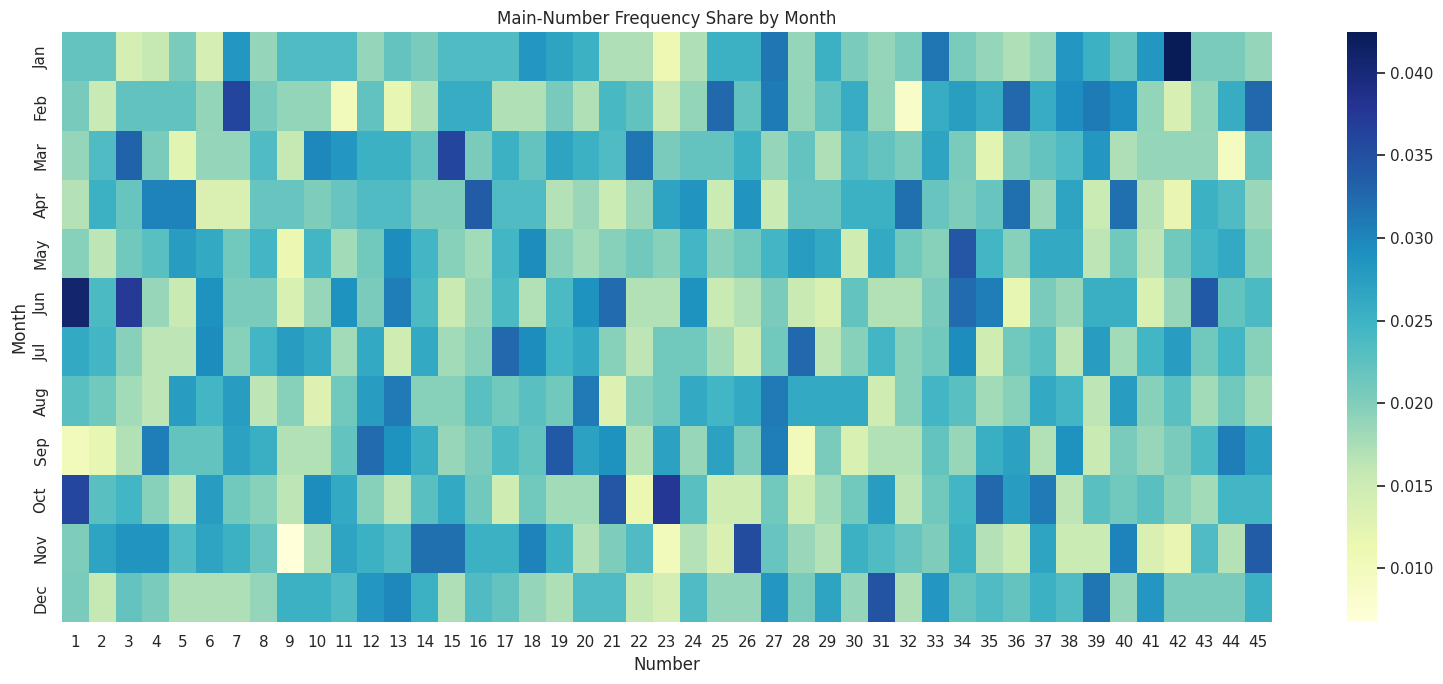

,group_col,group_value,draws,total_number_count,chi_square_stat,chi_square_p_value,kl_divergence_vs_overall
6,month_name,Jun,98,588,45.248732,0.419625,0.036730
10,month_name,Oct,102,612,42.429333,0.539079,0.032781
9,month_name,Nov,99,594,42.265769,0.546165,0.037156
0,month_name,Apr,99,594,40.547020,0.620414,0.033943
3,month_name,Feb,97,582,39.787411,0.652666,0.035129
4,month_name,Jan,106,636,38.644925,0.699833,0.028544
11,month_name,Sep,98,588,36.620321,0.777372,0.032391
7,month_name,Mar,106,636,32.650573,0.896207,0.025845
5,month_name,Jul,102,612,30.858316,0.932952,0.024809
1,month_name,Aug,102,612,23.537333,0.995108,0.019851


In [4]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

month_number_freq = build_context_number_frequency(df, 'month_name')
month_heatmap = month_number_freq.pivot(index='month_name', columns='number', values='share_within_group').reindex(month_order)

fig1, ax1 = plt.subplots(figsize=(16, 7))
sns.heatmap(month_heatmap, cmap='YlGnBu', ax=ax1)
ax1.set_title('Main-Number Frequency Share by Month')
ax1.set_xlabel('Number')
ax1.set_ylabel('Month')
plt.tight_layout()
plt.show()

month_frequency_tests = run_context_frequency_tests(df, 'month_name', min_draws=20)
month_frequency_tests


### 4. Pattern Distribution by Month

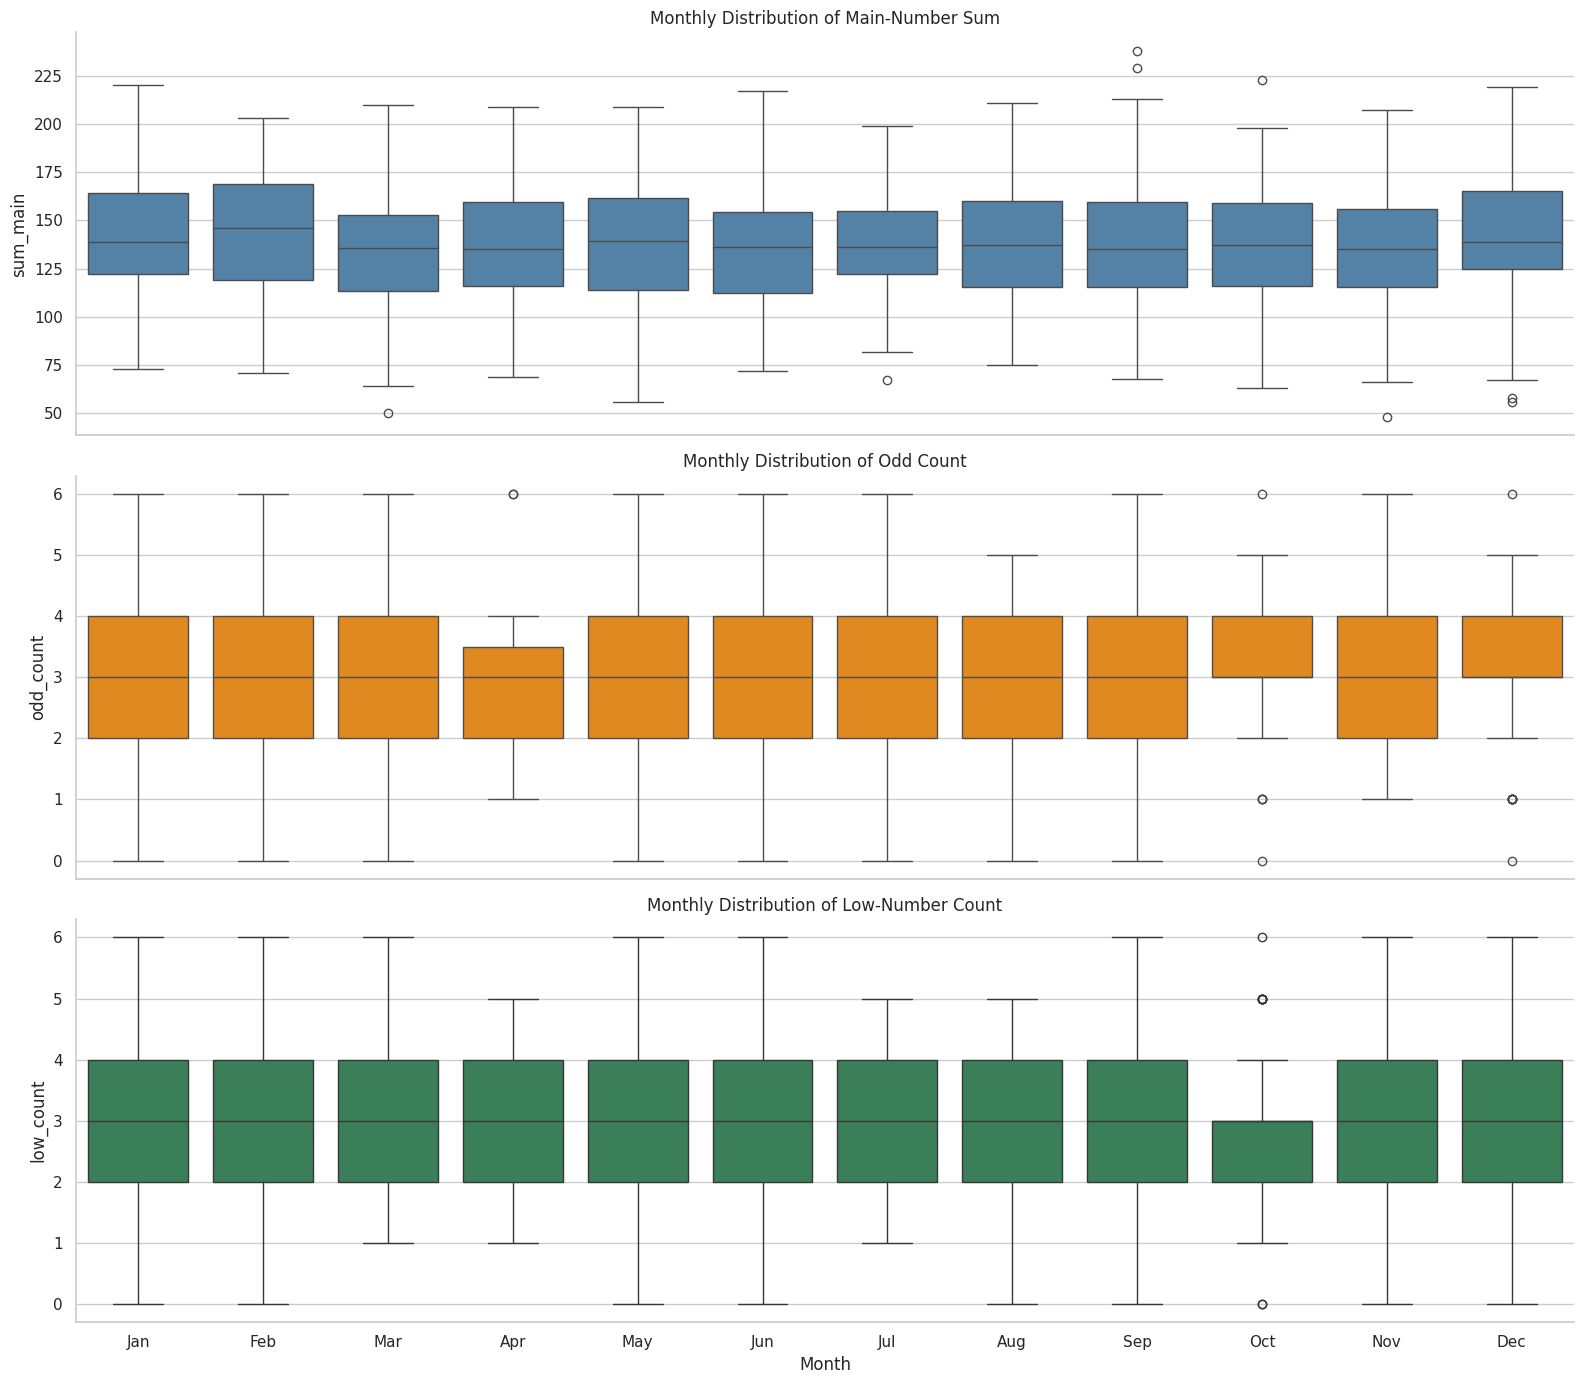

In [5]:
fig2, axes2 = plt.subplots(3, 1, figsize=(16, 14), sharex=True)
plot_df = df.copy()
plot_df['month_name'] = pd.Categorical(plot_df['month_name'], categories=month_order, ordered=True)
plot_df = plot_df.sort_values('month_name')

sns.boxplot(data=plot_df, x='month_name', y='sum_main', color='steelblue', ax=axes2[0])
axes2[0].set_title('Monthly Distribution of Main-Number Sum')
axes2[0].set_xlabel('')
axes2[0].set_ylabel('sum_main')

sns.boxplot(data=plot_df, x='month_name', y='odd_count', color='darkorange', ax=axes2[1])
axes2[1].set_title('Monthly Distribution of Odd Count')
axes2[1].set_xlabel('')
axes2[1].set_ylabel('odd_count')

sns.boxplot(data=plot_df, x='month_name', y='low_count', color='seagreen', ax=axes2[2])
axes2[2].set_title('Monthly Distribution of Low-Number Count')
axes2[2].set_xlabel('Month')
axes2[2].set_ylabel('low_count')

plt.tight_layout()
plt.show()


### 5. Number Distribution by Season

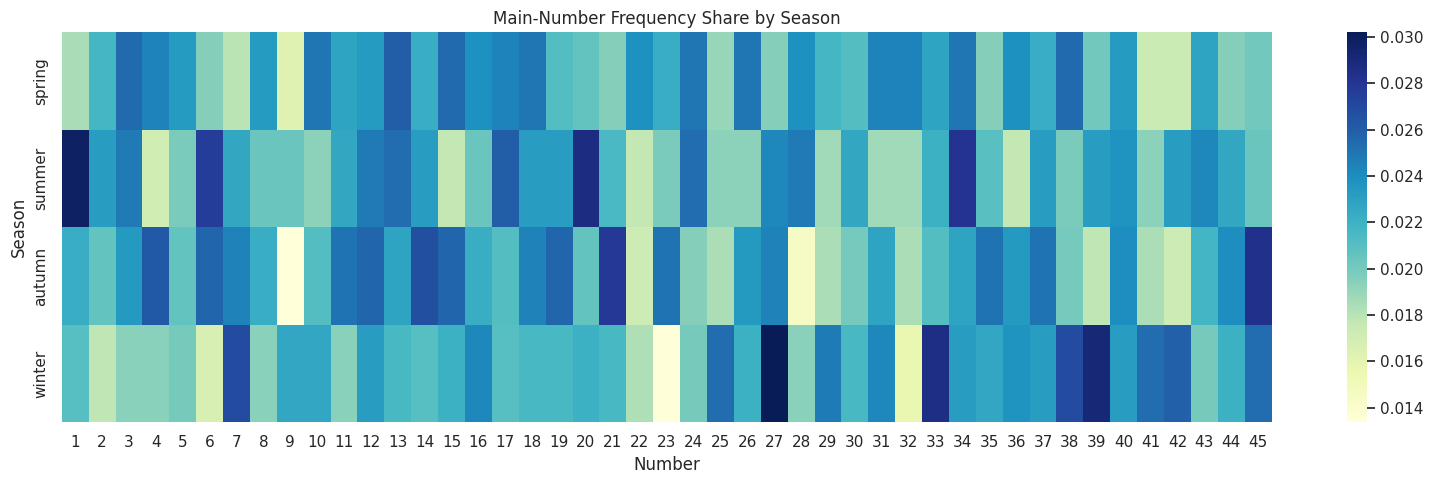

,group_col,group_value,draws,total_number_count,chi_square_stat,chi_square_p_value,kl_divergence_vs_overall
3,season,winter,309,1854,36.330111,0.787680,0.009728
0,season,autumn,299,1794,26.948815,0.979926,0.007592
2,season,summer,302,1812,26.226165,0.984639,0.007177
1,season,spring,307,1842,24.807697,0.991336,0.006780


In [6]:
season_order = ['spring', 'summer', 'autumn', 'winter']

season_number_freq = build_context_number_frequency(df, 'season')
season_heatmap = season_number_freq.pivot(index='season', columns='number', values='share_within_group').reindex(season_order)

fig3, ax3 = plt.subplots(figsize=(16, 5))
sns.heatmap(season_heatmap, cmap='YlGnBu', ax=ax3)
ax3.set_title('Main-Number Frequency Share by Season')
ax3.set_xlabel('Number')
ax3.set_ylabel('Season')
plt.tight_layout()
plt.show()

season_frequency_tests = run_context_frequency_tests(df, 'season', min_draws=20)
season_frequency_tests


### 6. Number Distribution by Year

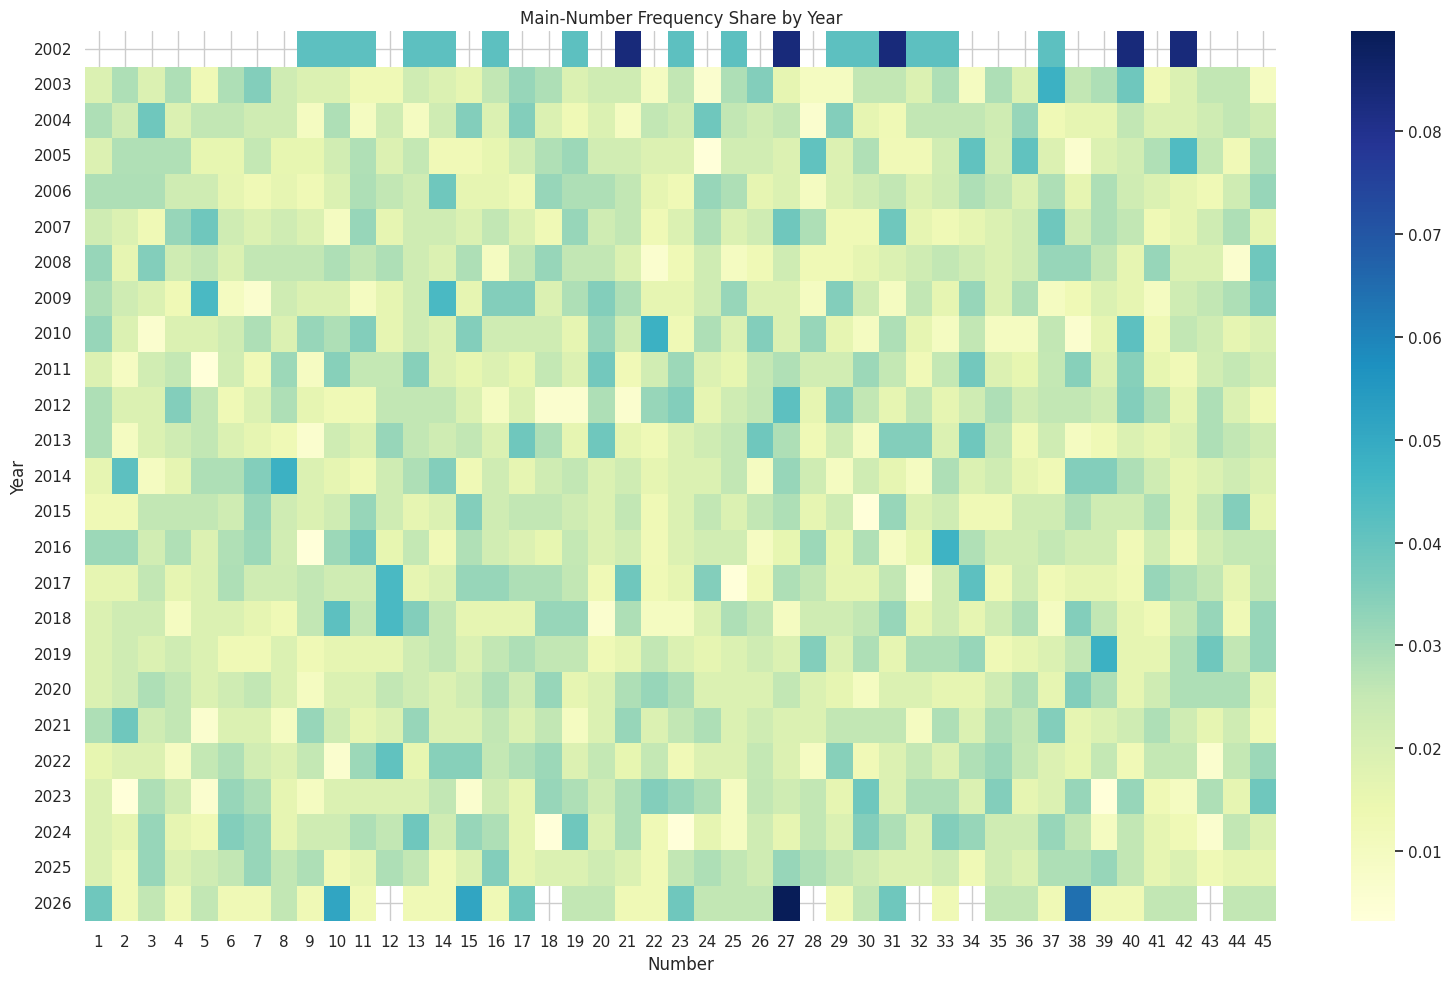

,group_col,group_value,draws,total_number_count,chi_square_stat,chi_square_p_value,kl_divergence_vs_overall
7,year,2010,52,312,56.991213,0.090506,0.089957
6,year,2009,52,312,56.200742,0.102691,0.090539
20,year,2023,52,312,52.482996,0.178260,0.094025
2,year,2005,53,318,47.771066,0.322146,0.076317
15,year,2018,52,312,47.250873,0.341242,0.078376
11,year,2014,52,312,46.495665,0.369951,0.071010
9,year,2012,52,312,46.355836,0.375387,0.079049
21,year,2024,52,312,45.684141,0.401986,0.083227
0,year,2003,52,312,44.817862,0.437353,0.074881
14,year,2017,52,312,43.844798,0.478229,0.073332


In [7]:
year_number_freq = build_context_number_frequency(df, 'year')
year_order = sorted(df['year'].dropna().unique().tolist())
year_heatmap = year_number_freq.pivot(index='year', columns='number', values='share_within_group').reindex(year_order)

fig4, ax4 = plt.subplots(figsize=(16, 10))
sns.heatmap(year_heatmap, cmap='YlGnBu', ax=ax4)
ax4.set_title('Main-Number Frequency Share by Year')
ax4.set_xlabel('Number')
ax4.set_ylabel('Year')
plt.tight_layout()
plt.show()

year_frequency_tests = run_context_frequency_tests(df, 'year', min_draws=20)
year_frequency_tests.head(10)


### 7. Pattern Distribution by Year

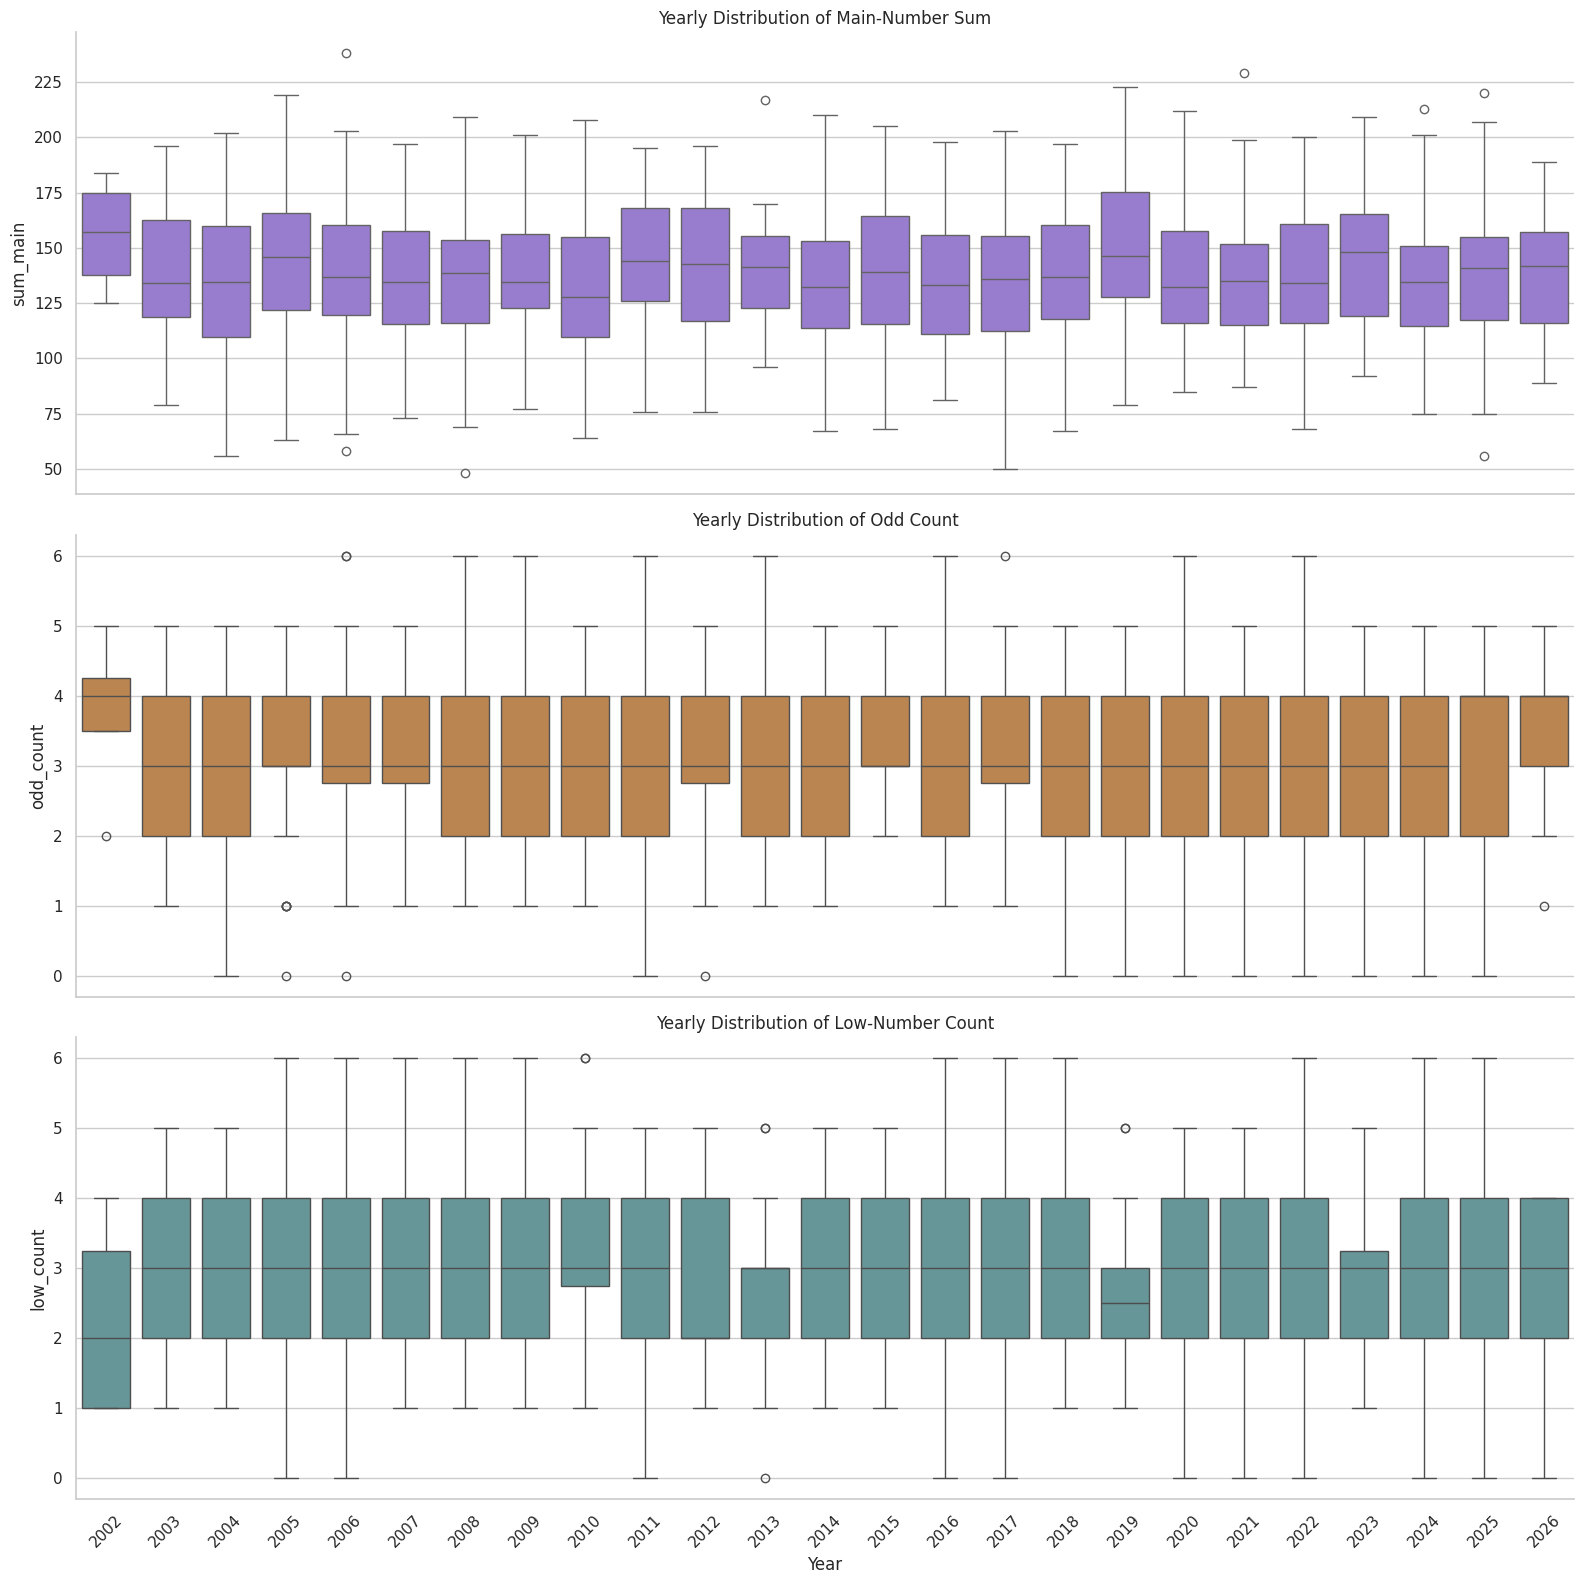

In [8]:
fig5, axes5 = plt.subplots(3, 1, figsize=(16, 16), sharex=True)
plot_df = df.sort_values('year').copy()

sns.boxplot(data=plot_df, x='year', y='sum_main', color='mediumpurple', ax=axes5[0])
axes5[0].set_title('Yearly Distribution of Main-Number Sum')
axes5[0].set_xlabel('')
axes5[0].set_ylabel('sum_main')

sns.boxplot(data=plot_df, x='year', y='odd_count', color='peru', ax=axes5[1])
axes5[1].set_title('Yearly Distribution of Odd Count')
axes5[1].set_xlabel('')
axes5[1].set_ylabel('odd_count')

sns.boxplot(data=plot_df, x='year', y='low_count', color='cadetblue', ax=axes5[2])
axes5[2].set_title('Yearly Distribution of Low-Number Count')
axes5[2].set_xlabel('Year')
axes5[2].set_ylabel('low_count')
for ax in axes5:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 8. Day-of-Month Analysis

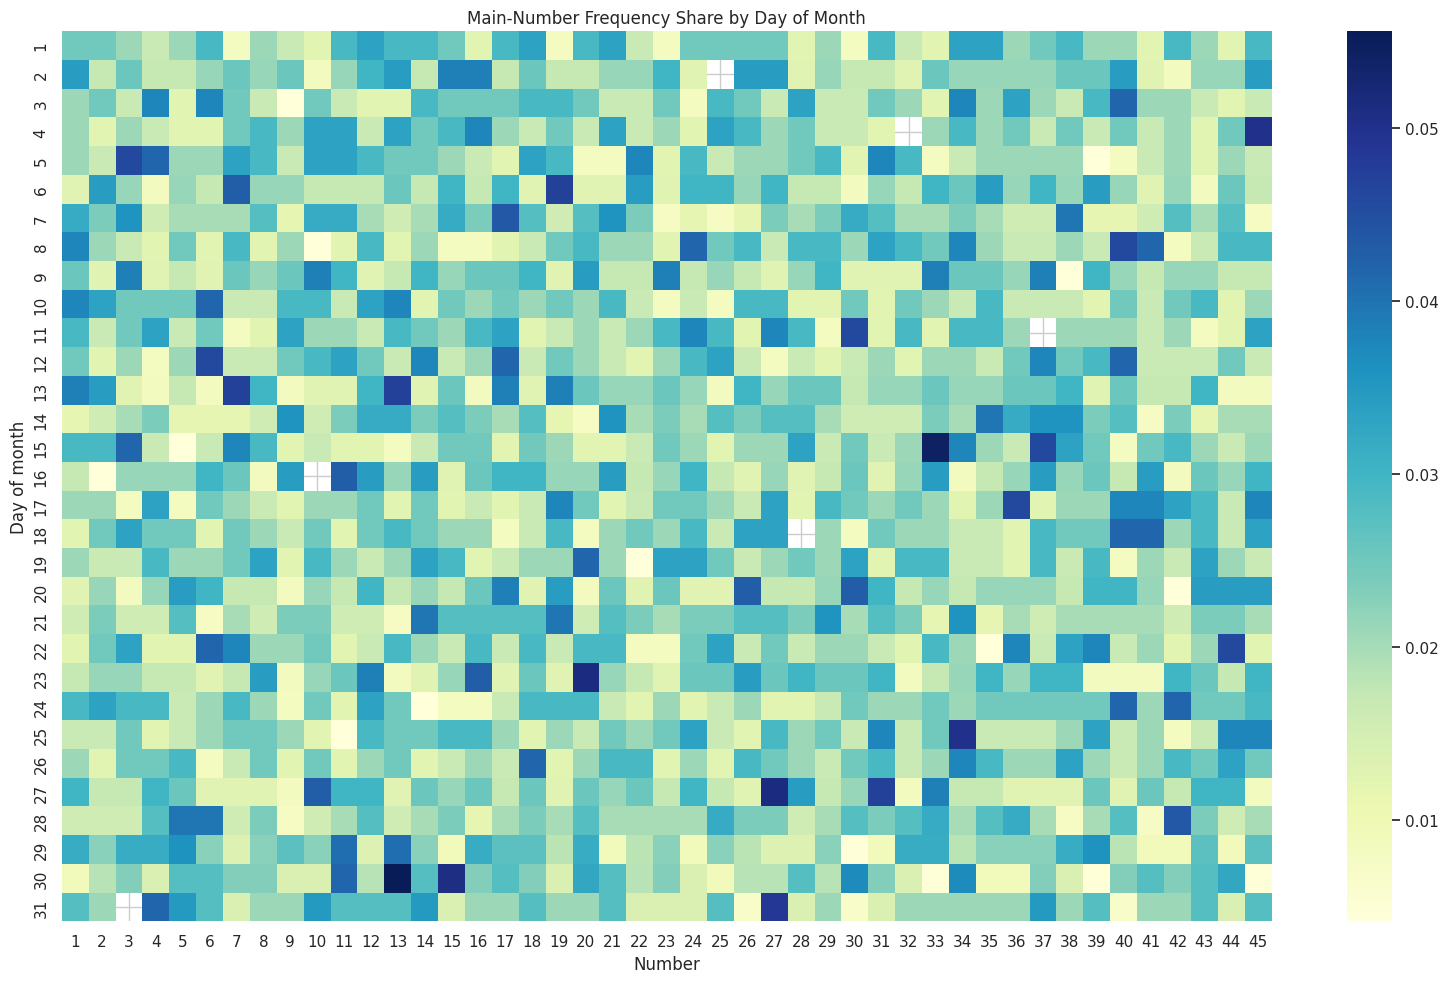

,group_col,group_value,draws,total_number_count,chi_square_stat,chi_square_p_value,kl_divergence_vs_overall
29,day_of_month,30,36,216,49.805902,0.253344,0.117577
14,day_of_month,15,40,240,46.464399,0.371163,0.095103
7,day_of_month,8,40,240,45.389170,0.413904,0.096444
12,day_of_month,13,39,234,44.636600,0.444885,0.096913
26,day_of_month,27,39,234,44.544086,0.448745,0.091604
4,day_of_month,5,40,240,43.913513,0.475310,0.094387
10,day_of_month,11,40,240,43.711180,0.483917,0.101576
21,day_of_month,22,40,240,41.084262,0.597322,0.085688
22,day_of_month,23,39,234,40.519262,0.621601,0.086663
19,day_of_month,20,39,234,38.538265,0.704131,0.083545


In [9]:
day_number_freq = build_context_number_frequency(df, 'day_of_month')
day_order = sorted(df['day_of_month'].dropna().unique().tolist())
day_heatmap = day_number_freq.pivot(index='day_of_month', columns='number', values='share_within_group').reindex(day_order)

fig6, ax6 = plt.subplots(figsize=(16, 10))
sns.heatmap(day_heatmap, cmap='YlGnBu', ax=ax6)
ax6.set_title('Main-Number Frequency Share by Day of Month')
ax6.set_xlabel('Number')
ax6.set_ylabel('Day of month')
plt.tight_layout()
plt.show()

day_frequency_tests = run_context_frequency_tests(df, 'day_of_month', min_draws=5)
day_frequency_tests.head(10)


### 9. Pattern Distribution by Day of Month

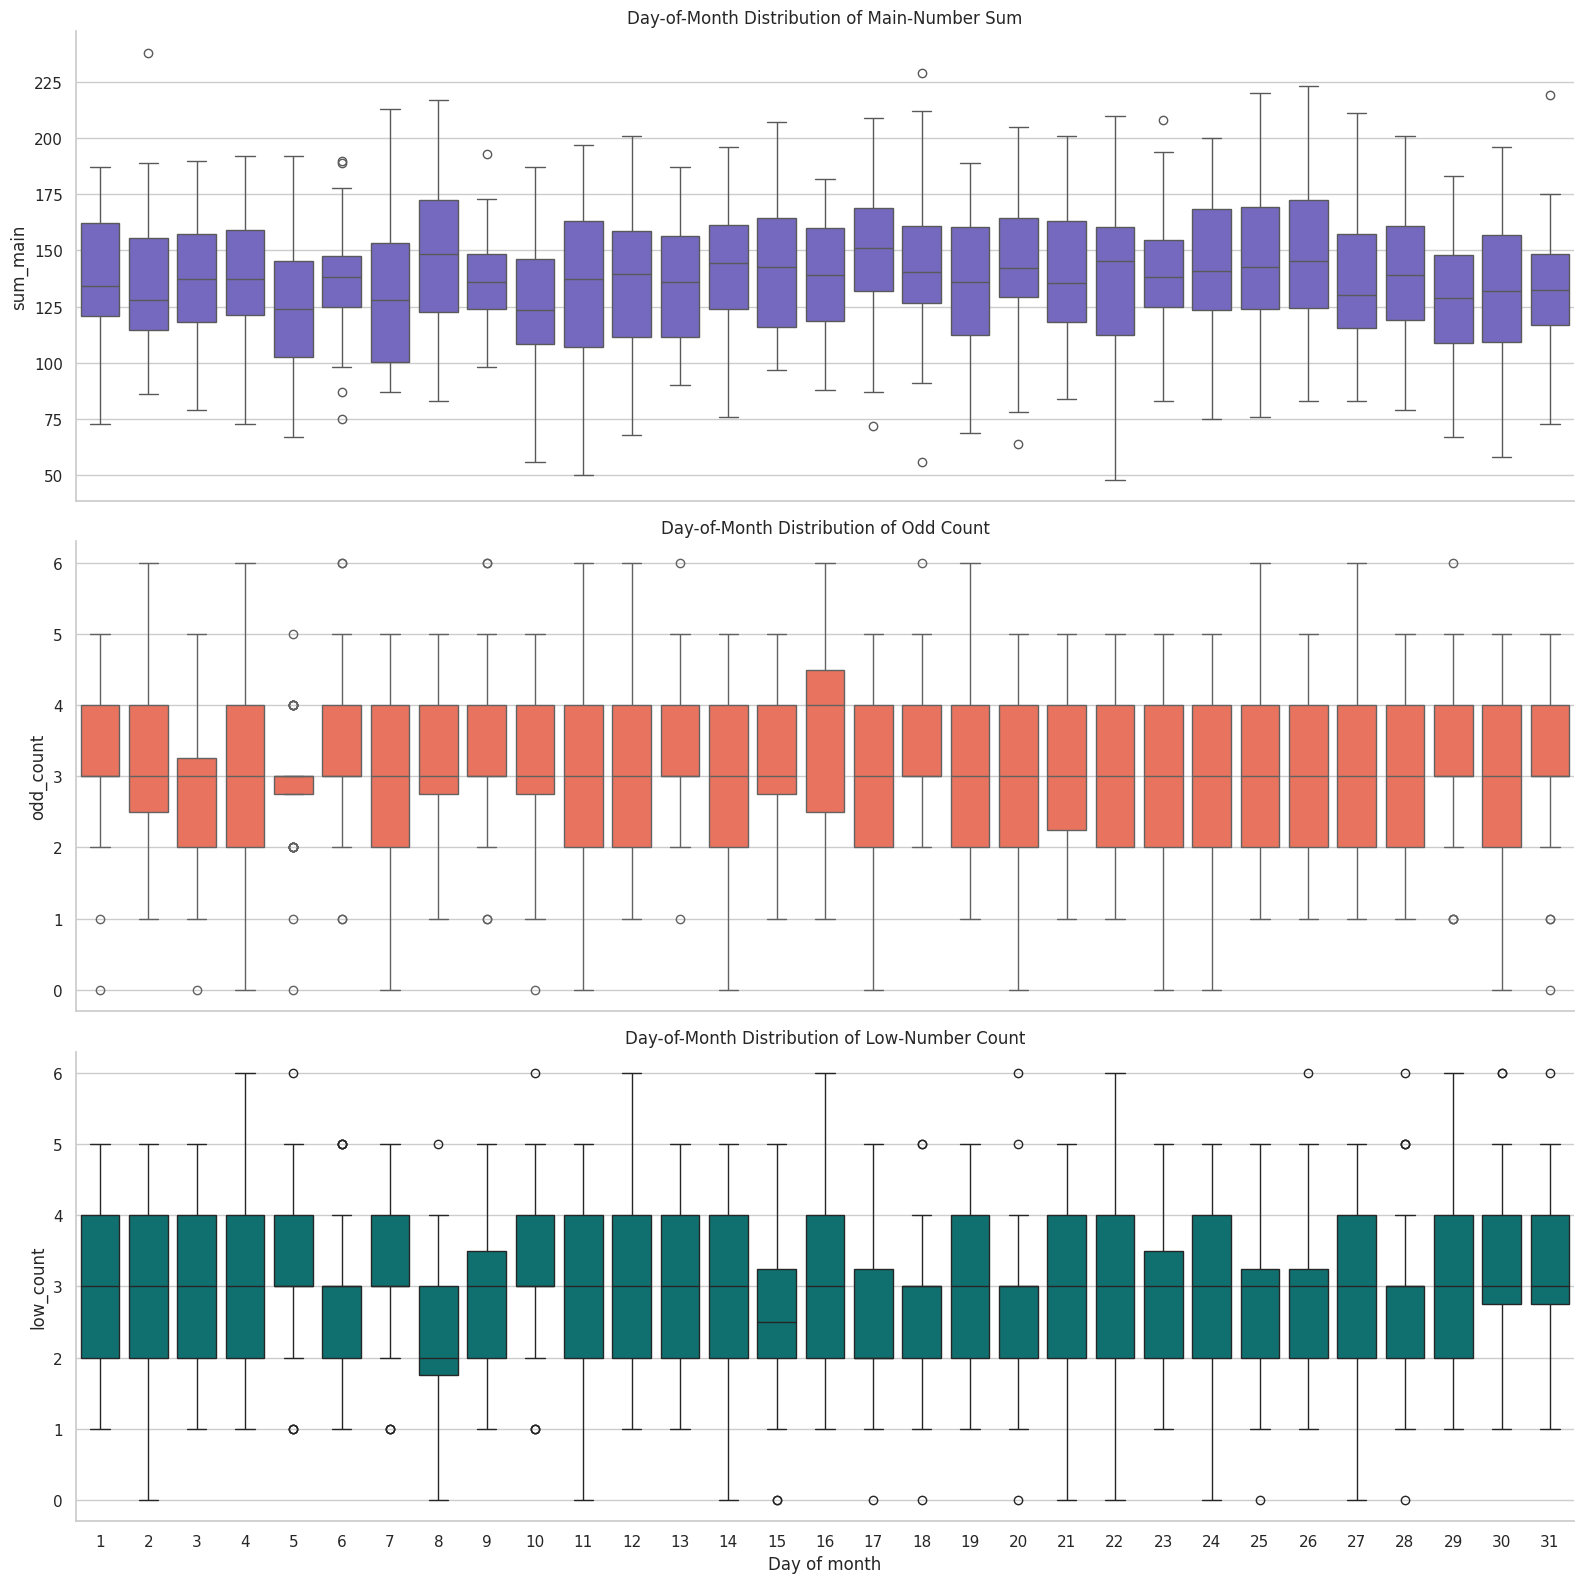

In [10]:
fig7, axes7 = plt.subplots(3, 1, figsize=(16, 16), sharex=True)
plot_df = df.sort_values('day_of_month').copy()

sns.boxplot(data=plot_df, x='day_of_month', y='sum_main', color='slateblue', ax=axes7[0])
axes7[0].set_title('Day-of-Month Distribution of Main-Number Sum')
axes7[0].set_xlabel('')
axes7[0].set_ylabel('sum_main')

sns.boxplot(data=plot_df, x='day_of_month', y='odd_count', color='tomato', ax=axes7[1])
axes7[1].set_title('Day-of-Month Distribution of Odd Count')
axes7[1].set_xlabel('')
axes7[1].set_ylabel('odd_count')

sns.boxplot(data=plot_df, x='day_of_month', y='low_count', color='teal', ax=axes7[2])
axes7[2].set_title('Day-of-Month Distribution of Low-Number Count')
axes7[2].set_xlabel('Day of month')
axes7[2].set_ylabel('low_count')

plt.tight_layout()
plt.show()


### 10. Pattern Summary Tests

In [11]:
month_pattern_tests = run_context_mean_tests(df, 'month_name')
season_pattern_tests = run_context_mean_tests(df, 'season')
year_pattern_tests = run_context_mean_tests(df, 'year')
day_pattern_tests = run_context_mean_tests(df, 'day_of_month', min_group_size=5)

context_pattern_test_summary = pd.concat([
    month_pattern_tests.assign(scope='month'),
    season_pattern_tests.assign(scope='season'),
    year_pattern_tests.assign(scope='year'),
    day_pattern_tests.assign(scope='day_of_month'),
], ignore_index=True)

context_pattern_test_summary


,group_col,metric,n_groups_tested,anova_stat,anova_p_value,kruskal_stat,kruskal_p_value,scope
0,month_name,sum_main,12,1.354935,1.886166e-01,13.033352,2.911511e-01,month
1,month_name,odd_count,12,1.454630,1.428146e-01,18.165170,7.782636e-02,month
2,month_name,low_count,12,1.716647,6.465639e-02,15.328186,1.679600e-01,month
3,month_name,winner_count,12,1.143172,3.233065e-01,18.600800,6.864659e-02,month
4,month_name,prize_amount,12,1.033623,4.137168e-01,21.746095,2.641574e-02,month
5,season,sum_main,4,3.189198,2.297257e-02,9.667080,2.161876e-02,season
6,season,odd_count,4,2.065157,1.030724e-01,6.356971,9.547714e-02,season
7,season,low_count,4,2.734691,4.243793e-02,7.024094,7.113375e-02,season
8,season,winner_count,4,1.165186,3.218054e-01,5.665963,1.290424e-01,season
9,season,prize_amount,4,1.254126,2.887972e-01,5.258011,1.538503e-01,season


### 11. Interpretation Notes

This notebook now treats **number frequency distributions** as the primary object of comparison and uses **sum_main / odd_count / low_count** as secondary pattern summaries.

A small p-value in the pattern tests does not automatically imply a stable lotto signal. The stronger question is whether the grouped number distributions look materially different from the overall distribution and whether those differences are large enough to matter.


### Report Export

In [12]:
save_report_figure(fig1, 'fig_11_context_month_number_heatmap.png')
save_report_figure(fig2, 'fig_12_context_month_pattern_boxplots.png')
save_report_figure(fig3, 'fig_13_context_season_number_heatmap.png')
save_report_figure(fig4, 'fig_14_context_year_number_heatmap.png')
save_report_figure(fig5, 'fig_15_context_year_pattern_boxplots.png')
save_report_figure(fig6, 'fig_16_context_day_number_heatmap.png')
save_report_figure(fig7, 'fig_17_context_day_pattern_boxplots.png')

save_report_table(month_frequency_tests, 'table_10_context_month_frequency_tests.csv')
save_report_table(season_frequency_tests, 'table_11_context_season_frequency_tests.csv')
save_report_table(year_frequency_tests, 'table_12_context_year_frequency_tests.csv')
save_report_table(day_frequency_tests, 'table_13_context_day_frequency_tests.csv')
save_report_table(context_pattern_test_summary, 'table_14_context_pattern_test_summary.csv')

plt.close(fig1)
plt.close(fig2)
plt.close(fig3)
plt.close(fig4)
plt.close(fig5)
plt.close(fig6)
plt.close(fig7)
print('Saved contextual distribution analysis report artifacts.')


Saved contextual distribution analysis report artifacts.
